In [71]:
import pandas as pd
df = pd.read_csv('./ML_dataset/homeprices2.csv')
df

,town,area,price
0,monroe township,2600,550000
1,monroe township,3000,565000
2,monroe township,3200,610000
3,monroe township,3600,680000
4,monroe township,4000,725000
5,west windsor,2600,585000
6,west windsor,2800,615000
7,west windsor,3300,650000
8,west windsor,3600,710000
9,robinsville,2600,575000


In [4]:
dummies = pd.get_dummies(df.town)
dummies

,monroe township,robinsville,west windsor
0,True,False,False
1,True,False,False
2,True,False,False
3,True,False,False
4,True,False,False
5,False,False,True
6,False,False,True
7,False,False,True
8,False,False,True
9,False,True,False


In [5]:
merged = pd.concat([df, dummies], axis='columns')
merged

,town,area,price,monroe township,robinsville,west windsor
0,monroe township,2600,550000,True,False,False
1,monroe township,3000,565000,True,False,False
2,monroe township,3200,610000,True,False,False
3,monroe township,3600,680000,True,False,False
4,monroe township,4000,725000,True,False,False
5,west windsor,2600,585000,False,False,True
6,west windsor,2800,615000,False,False,True
7,west windsor,3300,650000,False,False,True
8,west windsor,3600,710000,False,False,True
9,robinsville,2600,575000,False,True,False


In [6]:
final = merged.drop(['town', 'west windsor'], axis='columns')
final

,area,price,monroe township,robinsville
0,2600,550000,True,False
1,3000,565000,True,False
2,3200,610000,True,False
3,3600,680000,True,False
4,4000,725000,True,False
5,2600,585000,False,False
6,2800,615000,False,False
7,3300,650000,False,False
8,3600,710000,False,False
9,2600,575000,False,True


In [7]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [8]:
X = final.drop('price', axis='columns')
X

,area,monroe township,robinsville
0,2600,True,False
1,3000,True,False
2,3200,True,False
3,3600,True,False
4,4000,True,False
5,2600,False,False
6,2800,False,False
7,3300,False,False
8,3600,False,False
9,2600,False,True


In [9]:
y = final.price
y

0     550000
1     565000
2     610000
3     680000
4     725000
5     585000
6     615000
7     650000
8     710000
9     575000
10    600000
11    620000
12    695000
Name: price, dtype: int64

In [10]:
model.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
# import joblib
# joblib.dump(model, 'model_onehotenc')
# ohe = joblib.load('model_onehotenc')

In [13]:
model.predict([[2800,0,1]])

/home/raul/Github/Training/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([590775.63964739])

In [14]:
model.predict([[3400,0,0]])

/home/raul/Github/Training/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([681241.66845839])

In [15]:
model.score(X,y)

0.9573929037221872

In [16]:
df

,town,area,price
0,monroe township,2600,550000
1,monroe township,3000,565000
2,monroe township,3200,610000
3,monroe township,3600,680000
4,monroe township,4000,725000
5,west windsor,2600,585000
6,west windsor,2800,615000
7,west windsor,3300,650000
8,west windsor,3600,710000
9,robinsville,2600,575000


In [17]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [19]:
dfle = df
dfle.town = le.fit_transform(dfle.town)
dfle

,town,area,price
0,0,2600,550000
1,0,3000,565000
2,0,3200,610000
3,0,3600,680000
4,0,4000,725000
5,2,2600,585000
6,2,2800,615000
7,2,3300,650000
8,2,3600,710000
9,1,2600,575000


In [20]:
X = df[['town','area']].values
X

array([[   0, 2600],
       [   0, 3000],
       [   0, 3200],
       [   0, 3600],
       [   0, 4000],
       [   2, 2600],
       [   2, 2800],
       [   2, 3300],
       [   2, 3600],
       [   1, 2600],
       [   1, 2900],
       [   1, 3100],
       [   1, 3600]])

In [21]:
y = dfle.price
y

0     550000
1     565000
2     610000
3     680000
4     725000
5     585000
6     615000
7     650000
8     710000
9     575000
10    600000
11    620000
12    695000
Name: price, dtype: int64

In [32]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

column_transformers = ColumnTransformer(
    transformers=[
        ('ohe', OneHotEncoder(), [0])
    ],
    remainder='passthrough'
)

In [40]:
X = column_transformers.fit_transform(X)
X

array([[1.0e+00, 0.0e+00, 0.0e+00, 2.6e+03],
       [1.0e+00, 0.0e+00, 0.0e+00, 3.0e+03],
       [1.0e+00, 0.0e+00, 0.0e+00, 3.2e+03],
       [1.0e+00, 0.0e+00, 0.0e+00, 3.6e+03],
       [1.0e+00, 0.0e+00, 0.0e+00, 4.0e+03],
       [1.0e+00, 0.0e+00, 1.0e+00, 2.6e+03],
       [1.0e+00, 0.0e+00, 1.0e+00, 2.8e+03],
       [1.0e+00, 0.0e+00, 1.0e+00, 3.3e+03],
       [1.0e+00, 0.0e+00, 1.0e+00, 3.6e+03],
       [0.0e+00, 1.0e+00, 0.0e+00, 2.6e+03],
       [0.0e+00, 1.0e+00, 0.0e+00, 2.9e+03],
       [0.0e+00, 1.0e+00, 0.0e+00, 3.1e+03],
       [0.0e+00, 1.0e+00, 0.0e+00, 3.6e+03]])

In [44]:
X = X[:,1:]
X

array([[0.0e+00, 0.0e+00, 2.6e+03],
       [0.0e+00, 0.0e+00, 3.0e+03],
       [0.0e+00, 0.0e+00, 3.2e+03],
       [0.0e+00, 0.0e+00, 3.6e+03],
       [0.0e+00, 0.0e+00, 4.0e+03],
       [0.0e+00, 1.0e+00, 2.6e+03],
       [0.0e+00, 1.0e+00, 2.8e+03],
       [0.0e+00, 1.0e+00, 3.3e+03],
       [0.0e+00, 1.0e+00, 3.6e+03],
       [1.0e+00, 0.0e+00, 2.6e+03],
       [1.0e+00, 0.0e+00, 2.9e+03],
       [1.0e+00, 0.0e+00, 3.1e+03],
       [1.0e+00, 0.0e+00, 3.6e+03]])

In [45]:
model.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [46]:
model.predict([[1,0,2800]])

array([590775.63964739])

In [47]:
model.score(X,y)

0.9573929037221873

---

## Exercise

At the same level as this notebook on github, there is an Exercise folder that contains carprices.csv. This file has car sell prices for 3 different models. First plot data points on a scatter plot chart to see if linear regression model can be applied. If yes, then build a model that can answer following questions,

1) Predict price of a mercedez benz that is 4 yr old with mileage 45000

2) Predict price of a BMW X5 that is 7 yr old with mileage 86000

3) Tell me the score (accuracy) of your model. (Hint: use LinearRegression().score())

In [76]:
df = pd.read_csv('./ML_dataset/carprices.csv')
df

,Car Model,Mileage,Sell Price($),Age(yrs)
0,BMW X5,69000,18000,6
1,BMW X5,35000,34000,3
2,BMW X5,57000,26100,5
3,BMW X5,22500,40000,2
4,BMW X5,46000,31500,4
5,Audi A5,59000,29400,5
6,Audi A5,52000,32000,5
7,Audi A5,72000,19300,6
8,Audi A5,91000,12000,8
9,Mercedez Benz C class,67000,22000,6


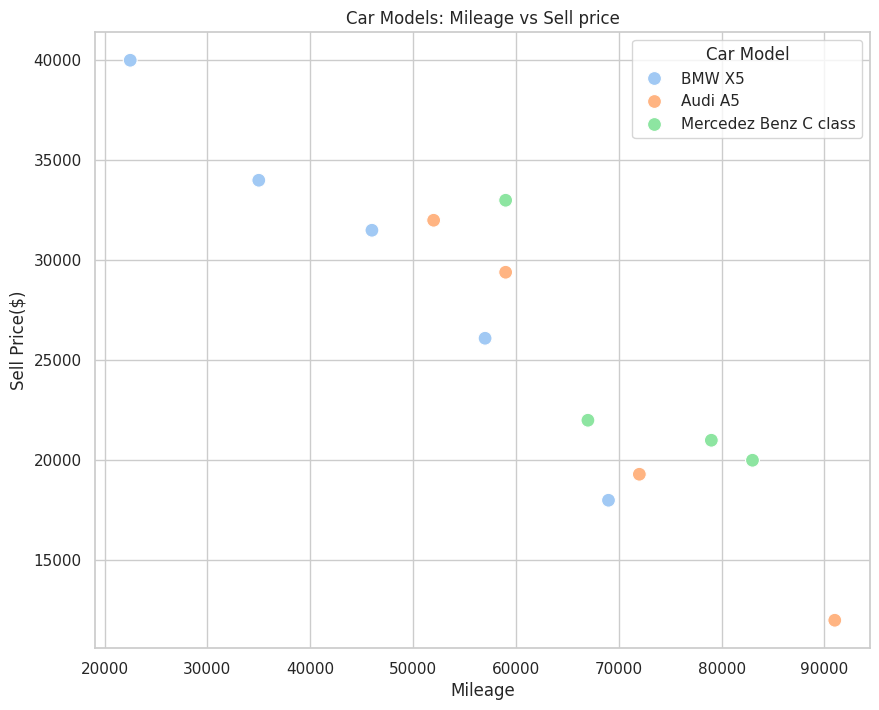

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))
sns.scatterplot(data=df, x='Mileage', y='Sell Price($)', hue="Car Model", s=100)

plt.title('Car Models: Mileage vs Sell price')
plt.grid(True)
plt.show()

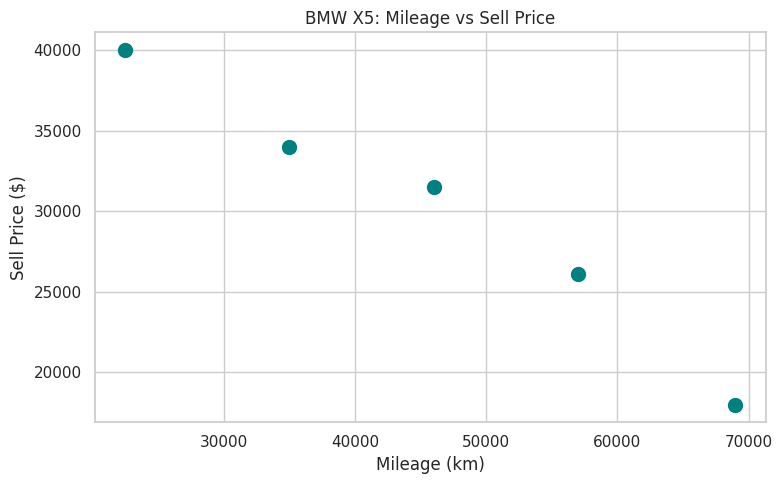

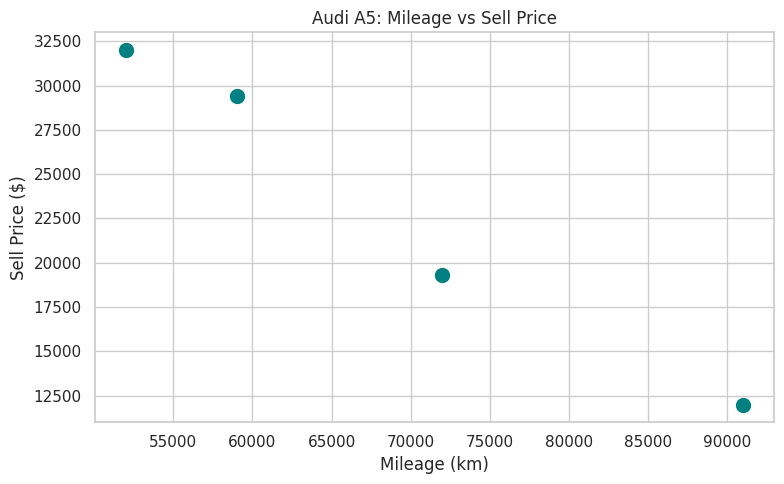

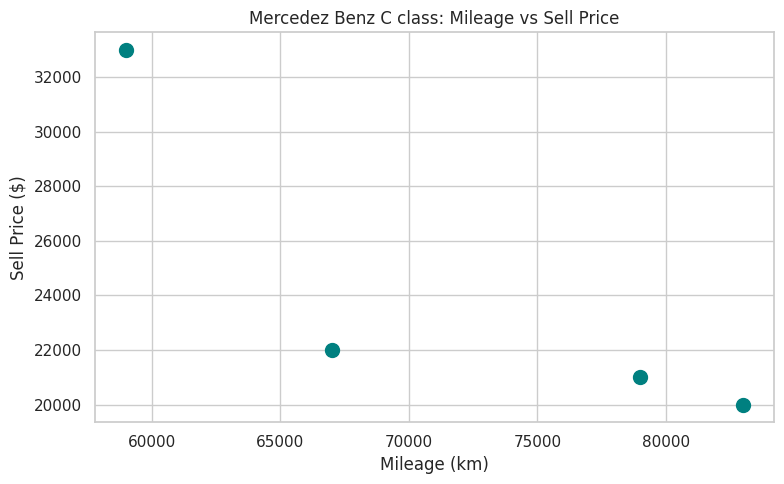

In [78]:
models = df['Car Model'].unique()

# Plot each model in a separate subplot
for model in models:
    subset = df[df['Car Model'] == model]

    plt.figure(figsize=(8, 5))
    plt.scatter(subset['Mileage'], subset['Sell Price($)'], color='teal', s=100)
    plt.title(f"{model}: Mileage vs Sell Price")
    plt.xlabel("Mileage (km)")
    plt.ylabel("Sell Price ($)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

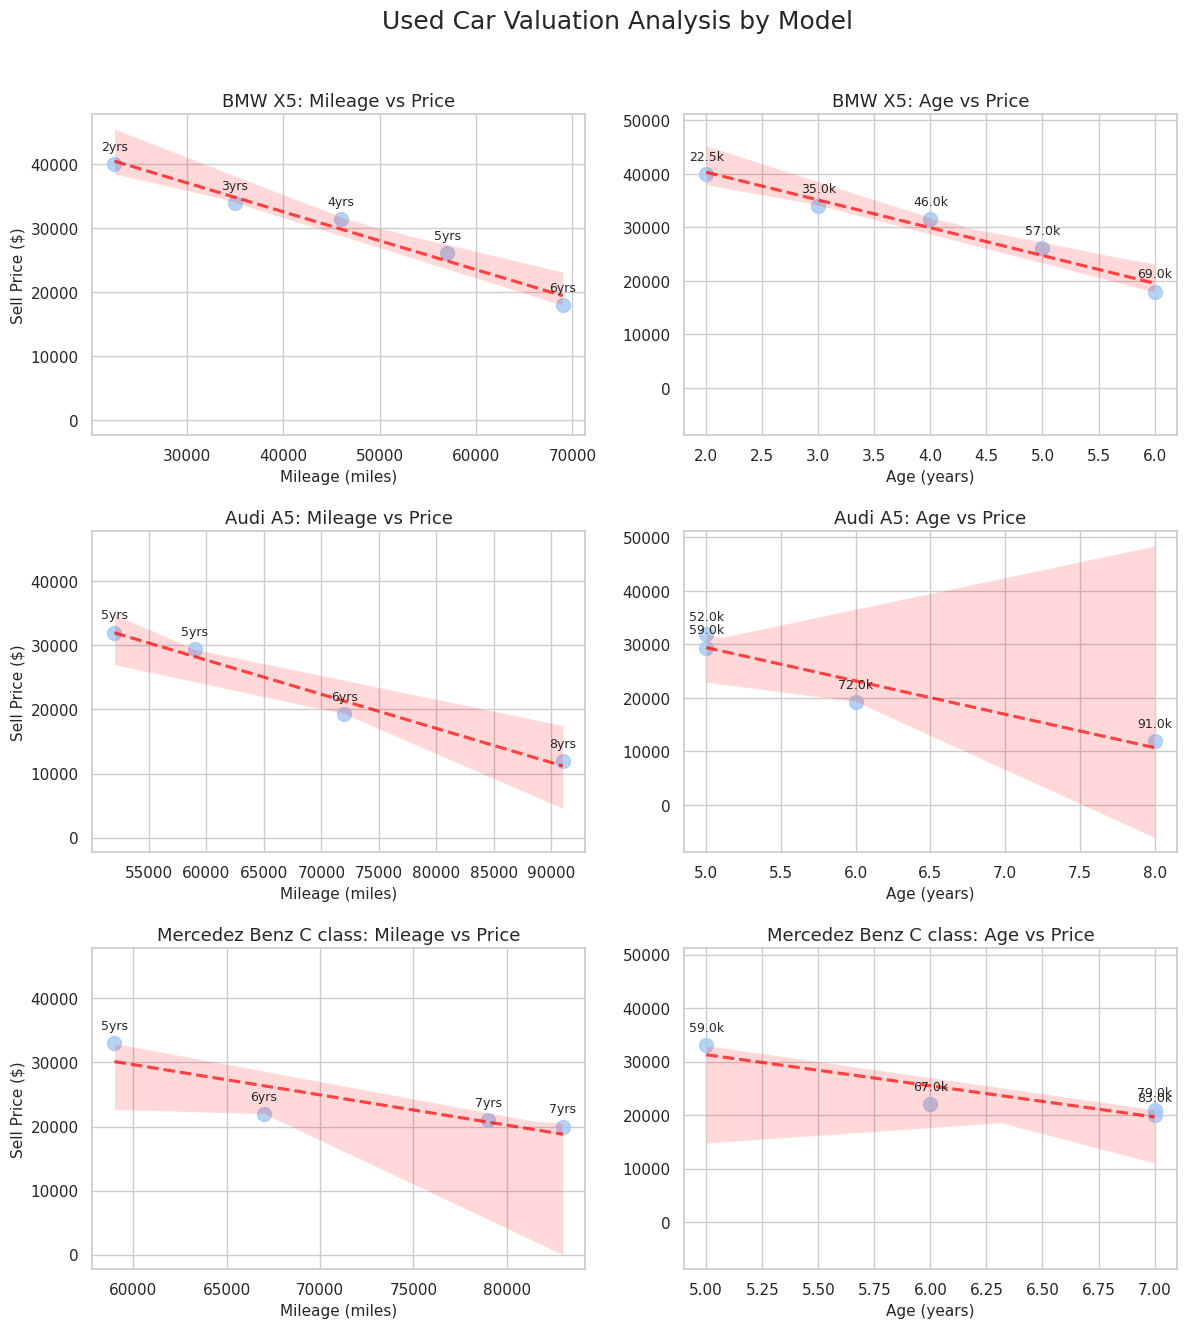

In [75]:
# Set up visualization
fig, axes = plt.subplots(3, 2, figsize=(14, 15), sharey='col')
plt.subplots_adjust(hspace=0.3, wspace=0.2)
sns.set_theme(style="whitegrid", palette="pastel")

# Plot each model's data
for i, model in enumerate(df['Car Model'].unique()):
    model_df = df[df['Car Model'] == model]
    
    # Mileage vs Price
    sns.regplot(
        x="Mileage", 
        y="Sell Price($)", 
        data=model_df, 
        ax=axes[i,0],
        scatter_kws={'s': 100, 'alpha': 0.8},
        line_kws={'color': 'red', 'linestyle': '--', 'alpha': 0.7}
    )
    axes[i,0].set_title(f"{model}: Mileage vs Price", fontsize=13)
    axes[i,0].set_xlabel("Mileage (miles)", fontsize=11)
    axes[i,0].set_ylabel("Sell Price ($)", fontsize=11)
    
    # Annotate data points
    for _, row in model_df.iterrows():
        axes[i,0].annotate(
            f"{row['Age(yrs)']}yrs", 
            (row['Mileage'], row['Sell Price($)']),
            textcoords="offset points", 
            xytext=(0,10),
            ha='center',
            fontsize=9
        )
    
    # Age vs Price
    sns.regplot(
        x="Age(yrs)", 
        y="Sell Price($)", 
        data=model_df, 
        ax=axes[i,1],
        scatter_kws={'s': 100, 'alpha': 0.8},
        line_kws={'color': 'red', 'linestyle': '--', 'alpha': 0.7}
    )
    axes[i,1].set_title(f"{model}: Age vs Price", fontsize=13)
    axes[i,1].set_xlabel("Age (years)", fontsize=11)
    axes[i,1].set_ylabel("")
    
    # Annotate data points
    for _, row in model_df.iterrows():
        axes[i,1].annotate(
            f"{row['Mileage']/1000:.1f}k", 
            (row['Age(yrs)'], row['Sell Price($)']),
            textcoords="offset points", 
            xytext=(0,10),
            ha='center',
            fontsize=9
        )

# Add overall title
fig.suptitle("Used Car Valuation Analysis by Model", fontsize=18, y=0.95)

# Save and show
plt.savefig('car_model_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [80]:
dfle = df
dfle['Car Model'] = le.fit_transform(dfle['Car Model'])
dfle

,Car Model,Mileage,Sell Price($),Age(yrs)
0,1,69000,18000,6
1,1,35000,34000,3
2,1,57000,26100,5
3,1,22500,40000,2
4,1,46000,31500,4
5,0,59000,29400,5
6,0,52000,32000,5
7,0,72000,19300,6
8,0,91000,12000,8
9,2,67000,22000,6


In [86]:
X = df[['Car Model', 'Mileage', 'Age(yrs)']]
X

,Car Model,Mileage,Age(yrs)
0,1,69000,6
1,1,35000,3
2,1,57000,5
3,1,22500,2
4,1,46000,4
5,0,59000,5
6,0,52000,5
7,0,72000,6
8,0,91000,8
9,2,67000,6


In [82]:
y = df['Sell Price($)']
y

0     18000
1     34000
2     26100
3     40000
4     31500
5     29400
6     32000
7     19300
8     12000
9     22000
10    20000
11    21000
12    33000
Name: Sell Price($), dtype: int64

In [87]:
model = LinearRegression()
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [90]:
model.predict([[2,45000,4]])

/home/raul/Github/Training/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([33336.7721827])

In [91]:
model.predict([[1,86000,7]])

/home/raul/Github/Training/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([16106.74127344])

In [92]:
model.score(X,y)

0.8719970367825953